In [43]:
# %pip install pandas
# %pip install scikit-learn
# %pip install tensorflow
# %pip install matplotlib
# %pip install imbalanced-learn

In [44]:
# %pip install --upgrade scikit-learn

%env SCIPY_ARRAY_API=1

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from utils import load_and_preprocess_data
from model import build_cnn_rnn_model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import recall_score
import csv
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt



env: SCIPY_ARRAY_API=1


In [ ]:
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(
    X_train.reshape(X_train.shape[0], -1), y_train
)

X_train_resampled = X_train_resampled.reshape(-1, X_train.shape[1], 1)

In [46]:
# 1. Load and preprocess the dataset
X_train, X_test, y_train, y_test = load_and_preprocess_data("../data/dataset.csv")

In [47]:
# 2. Build the model
model = build_cnn_rnn_model(input_shape=(X_train.shape[1], 1))

/Users/LucaZagaia/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight={0: 1.0, 1:5.0},
    callbacks=[early_stop]
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9641 - loss: 0.5496 - val_accuracy: 0.9594 - val_loss: 0.1770
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9565 - loss: 0.3453 - val_accuracy: 0.9406 - val_loss: 0.1832
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9512 - loss: 0.2981 - val_accuracy: 0.9513 - val_loss: 0.1563
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9526 - loss: 0.2800 - val_accuracy: 0.9519 - val_loss: 0.1567
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9552 - loss: 0.2703 - val_accuracy: 0.9475 - val_loss: 0.1656
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9562 - loss: 0.2842 - val_accuracy: 0.9544 - val_loss: 0.1439
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9535 - loss: 0.2787 - val_accuracy: 0.9469 - val_loss: 0.1637
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9577 - loss: 0.2597 - val_accu

In [49]:
# 4. Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9635 - loss: 0.1145
Test Accuracy: 0.9675


In [50]:
model.save("../results/cnn_rnn_model.h5")

with open("../results/metrics.csv", "w") as f:
    writer = csv.writer(f)
    writer.writerow(["Loss", "Accuracy"])
    writer.writerow([loss, accuracy])

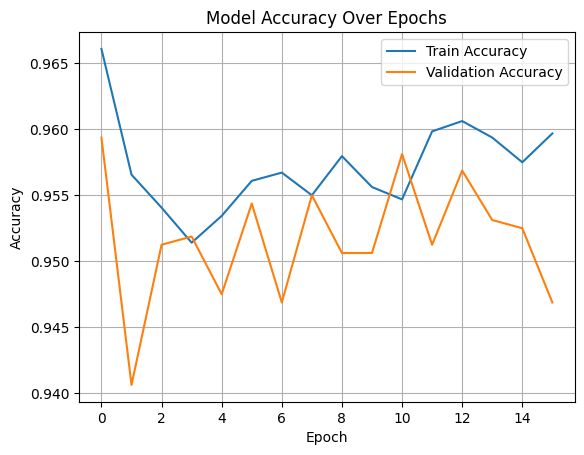

In [51]:


plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


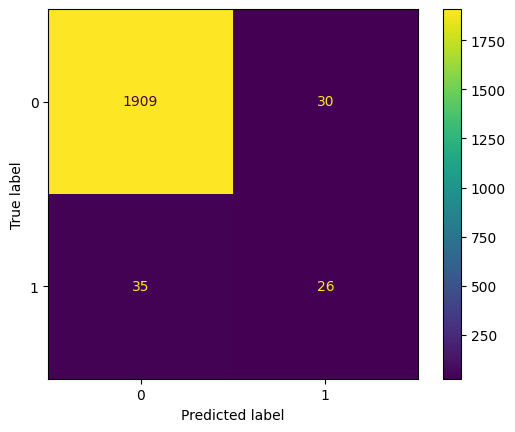

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred = model.predict(X_test).flatten()
y_pred_labels = np.where(y_pred > 0.5, 1, 0)

cm = confusion_matrix(y_test, y_pred_labels)
ConfusionMatrixDisplay(cm).plot()

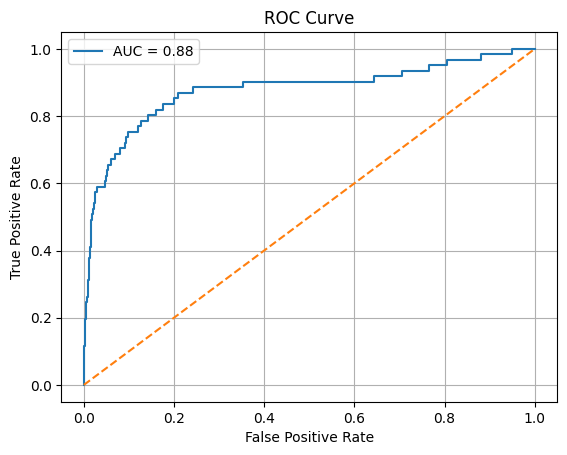

In [53]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [54]:
results = pd.DataFrame({
    "Prediction": y_pred_labels,
    "True Label": y_test.reset_index(drop=True)
})
results.to_csv("../results/predictions.csv", index=False)

In [55]:
recall = recall_score(y_test, y_pred_labels)
print(f"Failure recall: {recall:.4f}")

Failure recall: 0.4262


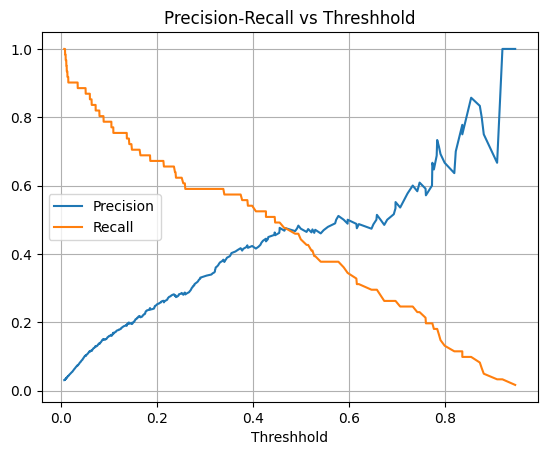

In [56]:
threshold = 0.3
y_pred_labels = (y_pred > threshold).astype(int)

# Compute precision-recall pairs
prec, rec, thresholds = precision_recall_curve(y_test, y_pred)

# Plot
plt.plot(thresholds, prec[:-1], label='Precision')
plt.plot(thresholds, rec[:-1], label='Recall')
plt.xlabel("Threshhold")
plt.legend()
plt.grid(True)
plt.title("Precision-Recall vs Threshhold")
plt.show()
